In [1]:
suppressPackageStartupMessages({
    library(ArchR) 
    library(data.table)
    library(purrr)
    library(parallel)
    library(dplyr)
    library(ggpubr)
    library(BSgenome)
    library(biomaRt)
    library(BSgenome.Ocuniculus.NCBI.oryCun2)
    library(GenomicFeatures)
    library(compEpiTools)
    library(GenomeInfoDb)
    library(stringi)
    library(AnnotationHub)
})


groupGOTerms: 	GOBPTerm, GOMFTerm, GOCCTerm environments built.

No methods found in package 'BiocGenerics' for requests: 'clusterApplyLB', 'clusterEvalQ' when loading 'methylPipe'

No methods found in package 'BiocGenerics' for requests: 'clusterApplyLB', 'clusterEvalQ' when loading 'compEpiTools'



In [2]:
# I/O
io = list()
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/'
io$output.directory <- file.path(io$basedir,"TEST")
setwd(file.path(io$output.directory, 'Archr'))

In [3]:
opts = list()
# Options
opts$min.fragments <- 2500
opts$filterTSS.score <- 5 # May need to rerun with threshold at 2

# ArchR options
addArchRThreads(threads = 1) 

Setting default number of Parallel threads to 1.



In [4]:
# Create genome annotation
genomeAnnotation <- createGenomeAnnotation(genome = BSgenome.Ocuniculus.NCBI.oryCun2)

Getting genome..

Getting chromSizes..

Getting blacklist..

Blacklist not downloaded! Continuing without, be careful for downstream biases..



In [5]:
# Create a gene annotation using Txdb file
rabbit_txdb <- makeTxDbFromBiomart(biomart="ensembl", dataset="ocuniculus_gene_ensembl")

taxid = taxonomyId(rabbit_txdb)
## If we don't have a package, then lets get the taxIds and AHIds
        ## for the hub objects
        loadNamespace("AnnotationHub")
        ah <- AnnotationHub::AnnotationHub()
        ah <- subset(ah, ah$rdataclass=='OrgDb') 
        mc <- mcols(ah)[,'taxonomyid', drop=FALSE]
        ## Then just get the object
        AHID <- rownames(mc[mc$taxonomyid==taxid,,drop=FALSE])
        rabbit_OrgDb <- ah[[AHID[2]]]

#rabbit_txdb
geneAnnotation <- createGeneAnnotation(
  TxDb  = rabbit_txdb,
    OrgDb =rabbit_OrgDb,
  TSS = TSS(rabbit_txdb), 
  exons = exons(rabbit_txdb)
)

Warning message:
"Ensembl will soon enforce the use of https.
Ensure the 'host' argument includes "https://""
Download and preprocess the 'transcripts' data frame ... 
OK

Download and preprocess the 'chrominfo' data frame ... 
OK

Download and preprocess the 'splicings' data frame ... 
OK

Download and preprocess the 'genes' data frame ... 
OK

Prepare the 'metadata' data frame ... 
OK

Make the TxDb object ... 
OK



<environment: namespace:AnnotationHub>

snapshotDate(): 2021-10-20

loading from cache

'select()' returned 1:1 mapping between keys and columns

Getting Genes..

Determined Annotation Style = ENSEMBL

Getting Exons..

Getting TSS..



In [6]:
geneAnnotation$genes
genomeAnnotation$chromSizes

GRanges object with 29587 ranges and 2 metadata columns:
          seqnames      ranges strand |            gene_id
             <Rle>   <IRanges>  <Rle> |        <character>
      [1]        1 15188-30378      + | ENSOCUG00000014251
      [2]        1 52453-53037      + | ENSOCUG00000005054
      [3]        1 57421-74905      - | ENSOCUG00000005046
      [4]        1 75200-85748      + | ENSOCUG00000005044
      [5]        1 92423-95845      - | ENSOCUG00000005040
      ...      ...         ...    ... .                ...
  [29583] GL019957 11177-12629      + | ENSOCUG00000037764
  [29584] GL019967   7995-8512      - | ENSOCUG00000036320
  [29585] GL019983     75-3969      - | ENSOCUG00000030662
  [29586] GL019983   1275-2315      + | ENSOCUG00000036489
  [29587] GL020024     21-1544      + | ENSOCUG00000026854
                         symbol
                    <character>
      [1] NA_ENSOCUG00000014251
      [2] NA_ENSOCUG00000005054
      [3] NA_ENSOCUG00000005046
      [4] NA_ENS

GRanges object with 22 ranges and 0 metadata columns:
       seqnames      ranges strand
          <Rle>   <IRanges>  <Rle>
   [1]     chr1 1-194850757      *
   [2]    chr10  1-47997241      *
   [3]    chr11  1-87554214      *
   [4]    chr12 1-155355395      *
   [5]    chr13 1-143360832      *
   ...      ...         ...    ...
  [18]     chr6  1-27502587      *
  [19]     chr7 1-173684459      *
  [20]     chr8 1-111795807      *
  [21]     chr9 1-116251907      *
  [22]     chrX 1-111700775      *
  -------
  seqinfo: 22 sequences from an unspecified genome

### UCSC w/o chr Prefix

In [ ]:
seqstyle = 'UCSC'
#seqstyle = 'NCBI'
seqlevelsStyle(genomeAnnotation$chromSizes) <- seqstyle
seqlevelsStyle(geneAnnotation$genes) <- seqstyle
seqlevelsStyle(geneAnnotation$TSS) <- seqstyle
seqlevelsStyle(geneAnnotation$exons) <- seqstyle
seqlevelsStyle(BSgenome.Ocuniculus.NCBI.oryCun2) <- seqstyle

#important as rabbit chromosome dont have the 'chr' prefix
    addArchRChrPrefix(chrPrefix = FALSE)

In [25]:
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC'
#fragment_files = "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/test_fragments.tsv.gz"
fragment_files = "/TEST/BGRGP4_fragments.tsv.gz"

In [28]:
opts$min.fragments <- 2500
opts$filterTSS.score <- 2.5 # May need to rerun with threshold at 2

#Create Arrow File for filtered samples, filtered using Signac's filter for ATAC
ArrowFiles <- createArrowFiles(
  inputFiles = paste0(io$basedir, fragment_files),
  sampleNames = paste0('rabbit'),
  minTSS = opts$filterTSS.score, #Dont set this too high because you can always increase later
  minFrags = opts$min.fragments , 
  addTileMat = TRUE,
  addGeneScoreMat = FALSE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation,
  force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW02

ArchR logging to : ArchRLogs/ArchR-createArrows-3f0c44a6ae06b-Date-2021-12-03_Time-16-20-48.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2021-12-03 16:20:48 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit : 1 of 1) Checking if completed file exists!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Arrow Exists! Overriding since force = TRUE!, 0 mins elapsed.

(rabbit : 1 of 1) Determining Arrow Method to use!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.003 mins elapsed.

2021-12-03 16:20:48 : (rabbit : 1 of 1) Tabix Bed To Temporary File, 0.004 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:1-38970151

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:38970152-77940302

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:77940303-116910454

(rabbit : 1 of 1) found fragments when removed chromosome pr

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:6231311-9346965

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:9346966-12462620

Warning message in sprintf("%s Reading TabixFile %s Percent", prefix, round(100 * :
"one argument not used by format '%s Reading TabixFile %s Percent'"
2021-12-03 16:37:27 : (rabbit : 1 of 1) Reading TabixFile 64 Percent, 16.65 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:12462621-15578276

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:1-31138221

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:31138222-62276442

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:62276443-93414663

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:93414664-124552884

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:124552885-155691105

(rabbit : 1 of 1) found fragments

2021-12-03 16:56:54 : (rabbit : 1 of 1) Removing Fragments from Filtered Cells, 36.103 mins elapsed.

2021-12-03 16:56:54 : (rabbit : 1 of 1) Creating Filtered Arrow File, 36.103 mins elapsed.

2021-12-03 16:57:56 : (rabbit : 1 of 1) Finished Constructing Filtered Arrow File!, 37.13 mins elapsed.

2021-12-03 16:57:56 : (rabbit : 1 of 1) Finished Creating Arrow File, 37.131 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-createArrows-3f0c44a6ae06b-Date-2021-12-03_Time-16-20-48.log



In [29]:
ArrowFiles = list.files(file.path(io$output.directory, 'Archr'), pattern ='arrow')

In [30]:
ArrowFiles

[1] "rabbit.arrow"

In [31]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW02

Validating Arrows...

Getting SampleNames...

1 


Copying ArrowFiles to Ouptut Directory! If you want to save disk space set copyArrows = FALSE

1 


Getting Cell Metadata...

1 


Merging Cell Metadata...

Initializing ArchRProject...


                                                   / |
                                                 /    \
            .                                  /      |.
            \\\                              /        |.
              \\\                          /           `|.
                \\\                      /              |.
                  \                    /                |\
                  \\#####\           /                  ||
                ==###########>      /                   ||
                 \\##==......\    /                     ||
            ______ =       =|__ /__                     ||      \\\
        ,--' ,----`-,__ ___/'  --,-`-===================##========>
       \               '        ##_______ ____

In [32]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/Archr/Project 
samples(1): rabbit
sampleColData names(1): ArrowFiles
cellColData names(11): Sample TSSEnrichment ... nFrags nDiFrags
numberOfCells(1): 2483
medianTSS(1): 3.441
medianFrags(1): 18194

In [33]:
proj@cellColData$CLUST = c(rep('A', 1000), rep('B', nrow(proj@cellColData)-1000))

In [34]:
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "CLUST")

ArchR logging to : ArchRLogs/ArchR-addGroupCoverages-3f0c44f64bb92-Date-2021-12-03_Time-16-57-58.log
If there is an issue, please report to github with logFile!

A (1 of 2) : CellGroups N = 2

B (2 of 2) : CellGroups N = 2

2021-12-03 16:57:58 : Creating Coverage Files!, 0.008 mins elapsed.

2021-12-03 16:57:58 : Batch Execution w/ safelapply!, 0.008 mins elapsed.

2021-12-03 16:57:58 : Group A._.Rep1 (1 of 4) : Creating Group Coverage File : A._.Rep1.insertions.coverage.h5, 0.008 mins elapsed.

Number of Cells = 500

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2021-12-03 16:58:52 : Group A._.Rep2 (2 of 4) : Creating Group Coverage File : A._.Rep2.insertions.coverage.h5, 0.915 mins elapsed.

Number of Cells = 40

Coverage File Exists!

Added Coverage Group

Added Metadata Group

Added ArrowCoverage Class

Added Coverage/Info

Added Coverage/Info/CellNames

2021-12-03 16:59:33 : Group B

In [38]:
pathToMacs2 <- findMacs2()

# Find peaks
proj <- addReproduciblePeakSet(
    ArchRProj = proj, 
    groupBy = "CLUST", 
   # pathToMacs2 = pathToMacs2
    peakMethod = "Macs2")


Searching For MACS2..

Found with $path!

Searching For MACS2..

Found with $path!

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-3f0c4a221190-Date-2021-12-03_Time-17-11-18.log
If there is an issue, please report to github with logFile!

Calling Peaks with Macs2

2021-12-03 17:11:19 : Peak Calling Parameters!, 0.008 mins elapsed.



  Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
A     A   1000        540           2   40  500   150000
B     B   1483        540           2   40  500   150000


2021-12-03 17:11:19 : Batching Peak Calls!, 0.008 mins elapsed.

2021-12-03 17:11:19 : Batch Execution w/ safelapply!, 0 mins elapsed.

2021-12-03 17:11:19 : Group 1 of 4, Calling Peaks with MACS2!, 0 mins elapsed.



ERROR: Error in (function (bedFile = NULL, pathToMacs2 = "macs2", genomeSize = 2.7e+09, : !is.null(genomeSize) is not TRUE


In [41]:
proj = addTileMatrix(proj, force=TRUE)

ArchR logging to : ArchRLogs/ArchR-addTileMatrix-3f0c462ed04a5-Date-2021-12-03_Time-17-13-35.log
If there is an issue, please report to github with logFile!

2021-12-03 17:13:36 : Batch Execution w/ safelapply!, 0 mins elapsed.

Can not create group. Object with name 'TileMatrix' already exists.

2021-12-03 17:13:44 : Adding TileMatrix to rabbit for Chr (1 of 22)!, 0.132 mins elapsed.

2021-12-03 17:13:51 : Adding TileMatrix to rabbit for Chr (2 of 22)!, 0.26 mins elapsed.

2021-12-03 17:14:01 : Adding TileMatrix to rabbit for Chr (3 of 22)!, 0.414 mins elapsed.

2021-12-03 17:14:07 : Adding TileMatrix to rabbit for Chr (4 of 22)!, 0.515 mins elapsed.

2021-12-03 17:14:13 : Adding TileMatrix to rabbit for Chr (5 of 22)!, 0.624 mins elapsed.

2021-12-03 17:14:20 : Adding TileMatrix to rabbit for Chr (6 of 22)!, 0.74 mins elapsed.

2021-12-03 17:14:27 : Adding TileMatrix to rabbit for Chr (7 of 22)!, 0.848 mins elapsed.

2021-12-03 17:14:32 : Adding TileMatrix to rabbit for Chr (8 of 22)

In [42]:
proj <- addReproduciblePeakSet(
    ArchRProj = proj, 
    groupBy = "CLUST",
    peakMethod = "Tiles",
    method = "p"
)

ArchR logging to : ArchRLogs/ArchR-addReproduciblePeakSet-3f0c4f178ffd-Date-2021-12-03_Time-17-16-25.log
If there is an issue, please report to github with logFile!

Calling Peaks with TileMatrix. We recommend using the Macs2 Version.
This method is still under development.

Group Coverages Already Computed Returning Groups, Set force = TRUE to Recompute!



List of length 2
names(2): A B


2021-12-03 17:16:25 : Peak Calling Parameters!, 0.008 mins elapsed.



  Group nCells nCellsUsed nReplicates nMin nMax maxPeaks
A     A   1000        540           2   40  500   150000
B     B   1483        540           2   40  500   150000


2021-12-03 17:16:27 : Computing Total Accessibility Across All Features, 0.033 mins elapsed.

2021-12-03 17:16:30 : Computing Pseudo-Grouped Tile Matrix, 0.08 mins elapsed.

2021-12-03 17:18:03 : Created Pseudo-Grouped Tile Matrix (0.403 GB), 1.639 mins elapsed.

colSums = 24170119colSums = 1963729colSums = 7436063colSums = 551523

nTiles = 4495514

Expectation = 5.37649732600099Expectation = 0.436819682910564Expectation = 1.65410740573825Expectation = 0.122682967954276

2021-12-03 17:18:04 : Computing Peaks from Tile Matrix Group (1 of 2), 1.645 mins elapsed.

2021-12-03 17:18:13 : Computing Peaks from Tile Matrix Group (2 of 2), 1.799 mins elapsed.

2021-12-03 17:18:19 : Creating Group Peak Sets with Annotations!, 1.903 mins elapsed.

Annotating Peaks : Nearest Gene

Annotating Peaks : Gene

Warning message in valid.GenomicRanges.seqinfo(x, suggest.trim = TRUE):
"GRanges object contains 3 out-of-bound ranges located on sequences
  chr12, chr13, and chr16. Note that ranges located on 

In [43]:
# Motif enrichment
proj <- addMotifAnnotations(ArchRProj = proj, motifSet = "cisbp", name = "Motif", species='Homo sapiens')

ArchR logging to : ArchRLogs/ArchR-addMotifAnnotations-3f0c45da8df3d-Date-2021-12-03_Time-17-21-27.log
If there is an issue, please report to github with logFile!

2021-12-03 17:21:41 : Gettting Motif Set, Species : Homo sapiens, 0.005 mins elapsed.

Using version 2 motifs!

2021-12-03 17:21:47 : Finding Motif Positions with motifmatchr!, 0.097 mins elapsed.

2021-12-03 17:26:43 : Creating Motif Overlap Matrix, 5.034 mins elapsed.

2021-12-03 17:26:47 : Finished Getting Motif Info!, 5.111 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-addMotifAnnotations-3f0c45da8df3d-Date-2021-12-03_Time-17-21-27.log



In [45]:
proj <- addPeakMatrix(proj)

ArchR logging to : ArchRLogs/ArchR-addPeakMatrix-3f0c47427a0e6-Date-2021-12-03_Time-17-28-07.log
If there is an issue, please report to github with logFile!

2021-12-03 17:28:07 : Batch Execution w/ safelapply!, 0 mins elapsed.

2021-12-03 17:28:08 : Adding rabbit to PeakMatrix for Chr (1 of 22)!, 0.008 mins elapsed.

2021-12-03 17:28:16 : Adding rabbit to PeakMatrix for Chr (2 of 22)!, 0.15 mins elapsed.

2021-12-03 17:28:23 : Adding rabbit to PeakMatrix for Chr (3 of 22)!, 0.267 mins elapsed.

2021-12-03 17:28:30 : Adding rabbit to PeakMatrix for Chr (4 of 22)!, 0.382 mins elapsed.

2021-12-03 17:28:37 : Adding rabbit to PeakMatrix for Chr (5 of 22)!, 0.486 mins elapsed.

2021-12-03 17:28:42 : Adding rabbit to PeakMatrix for Chr (6 of 22)!, 0.58 mins elapsed.

2021-12-03 17:28:48 : Adding rabbit to PeakMatrix for Chr (7 of 22)!, 0.671 mins elapsed.

2021-12-03 17:28:55 : Adding rabbit to PeakMatrix for Chr (8 of 22)!, 0.789 mins elapsed.

2021-12-03 17:29:01 : Adding rabbit to PeakMa

In [46]:
getAvailableMatrices(proj)

[1] "PeakMatrix" "TileMatrix"

In [47]:
markersPeaks <- getMarkerFeatures(
    ArchRProj = proj, 
    useMatrix = "PeakMatrix", 
    groupBy = "CLUST",
  bias = c("TSSEnrichment", "log10(nFrags)"),
  testMethod = "wilcoxon"
)

ArchR logging to : ArchRLogs/ArchR-getMarkerFeatures-3f0c47594955f-Date-2021-12-03_Time-17-30-54.log
If there is an issue, please report to github with logFile!

MatrixClass = Sparse.Integer.Matrix

2021-12-03 17:30:55 : Matching Known Biases, 0.003 mins elapsed.

2021-12-03 17:30:57 : Computing Pairwise Tests (1 of 2), 0.039 mins elapsed.

Pairwise Test A : Seqnames chr1

Pairwise Test A : Seqnames chr10

Pairwise Test A : Seqnames chr11

Pairwise Test A : Seqnames chr12

Pairwise Test A : Seqnames chr13

Pairwise Test A : Seqnames chr14

Pairwise Test A : Seqnames chr15

Pairwise Test A : Seqnames chr16

Pairwise Test A : Seqnames chr17

Pairwise Test A : Seqnames chr18

Pairwise Test A : Seqnames chr19

Pairwise Test A : Seqnames chr2

Pairwise Test A : Seqnames chr20

Pairwise Test A : Seqnames chr21

Pairwise Test A : Seqnames chr3

Pairwise Test A : Seqnames chr4

Pairwise Test A : Seqnames chr5

Pairwise Test A : Seqnames chr6

Pairwise Test A : Seqnames chr7

Pairwise Test A : 

In [49]:
markerList <- getMarkers(markersPeaks, cutOff = "FDR <= 0.01 & Log2FC >= 1")
markerList

List of length 2
names(2): A B

In [52]:
heatmapPeaks <- markerHeatmap(
  seMarker = markersPeaks, 
  cutOff = "FDR <= 0.1 & Log2FC >= 0.5",
  transpose = TRUE, plotLog2FC = TRUE
)

Warning message:
"'markerHeatmap' is deprecated.
Use 'plotMarkerHeatmap' instead.
See help("Deprecated")"
ArchR logging to : ArchRLogs/ArchR-plotMarkerHeatmap-3f0c453526982-Date-2021-12-03_Time-17-33-17.log
If there is an issue, please report to github with logFile!

Identified 31436 markers!



 [1] "chr1:10000-10499"         "chr1:15000-15499"        
 [3] "chr1:116500-116999"       "chr1:117000-117499"      
 [5] "chr1:124000-124499"       "chr1:127500-127999"      
 [7] "chr1:128000-128499"       "chr1:191000-191499"      
 [9] "chr1:191500-191999"       "chr1:202500-202999"      
[11] "chr1:330000-330499"       "chr1:352000-352499"      
[13] "chr1:394000-394499"       "chr1:394500-394999"      
[15] "chr1:475000-475499"       "chr1:14031000-14031499"  
[17] "chr1:18239000-18239499"   "chr1:49968000-49968499"  
[19] "chr1:63418500-63418999"   "chr1:75395500-75395999"  
[21] "chr1:121782500-121782999" "chr1:133644000-133644499"
[23] "chr1:141094000-141094499" "chr1:186070000-186070499"
[25] "chr10:19566000-19566499"  "chr11:30535500-30535999" 
[27] "chr11:70349000-70349499"  "chr12:23634500-23634999" 
[29] "chr12:26355000-26355499"  "chr12:26777500-26777999" 


Adding Annotations..

Preparing Main Heatmap..

'magick' package is suggested to install to give better rasterization.

Set `ht_opt$message = FALSE` to turn off this message.

ArchR logging successful to : ArchRLogs/ArchR-plotMarkerHeatmap-3f0c453526982-Date-2021-12-03_Time-17-33-17.log



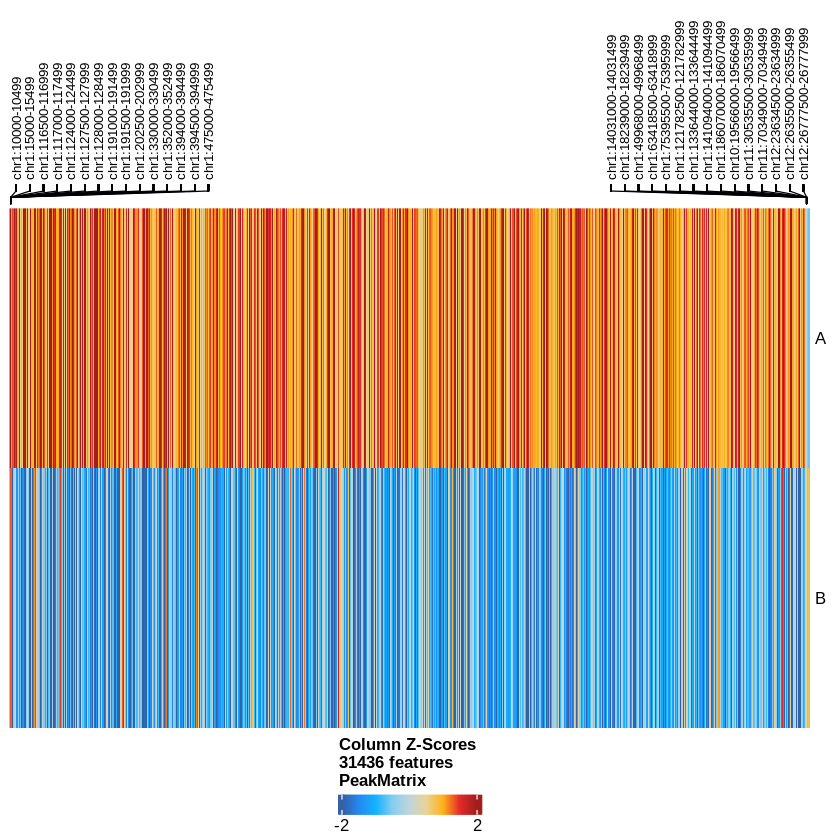

In [53]:
draw(heatmapPeaks, heatmap_legend_side = "bot", annotation_legend_side = "bot")

In [54]:
motifsUp <- peakAnnoEnrichment(
    seMarker = markersPeaks,
    ArchRProj = proj,
    peakAnnotation = "Motif",
    cutOff = "FDR <= 0.1 & Log2FC >= 0.5"
  )

ArchR logging to : ArchRLogs/ArchR-peakAnnoEnrichment-3f0c4743d9e70-Date-2021-12-03_Time-17-33-48.log
If there is an issue, please report to github with logFile!

2021-12-03 17:33:53 : Computing Enrichments 1 of 2, 0.085 mins elapsed.

2021-12-03 17:33:53 : Computing Enrichments 2 of 2, 0.095 mins elapsed.

ArchR logging successful to : ArchRLogs/ArchR-peakAnnoEnrichment-3f0c4743d9e70-Date-2021-12-03_Time-17-33-48.log



In [56]:
df <- data.frame(TF = rownames(motifsUp), mlog10Padj = assay(motifsUp)[,1])
df <- df[order(df$mlog10Padj, decreasing = TRUE),]
df$rank <- seq_len(nrow(df))

Warning message:
"ggrepel: 21 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


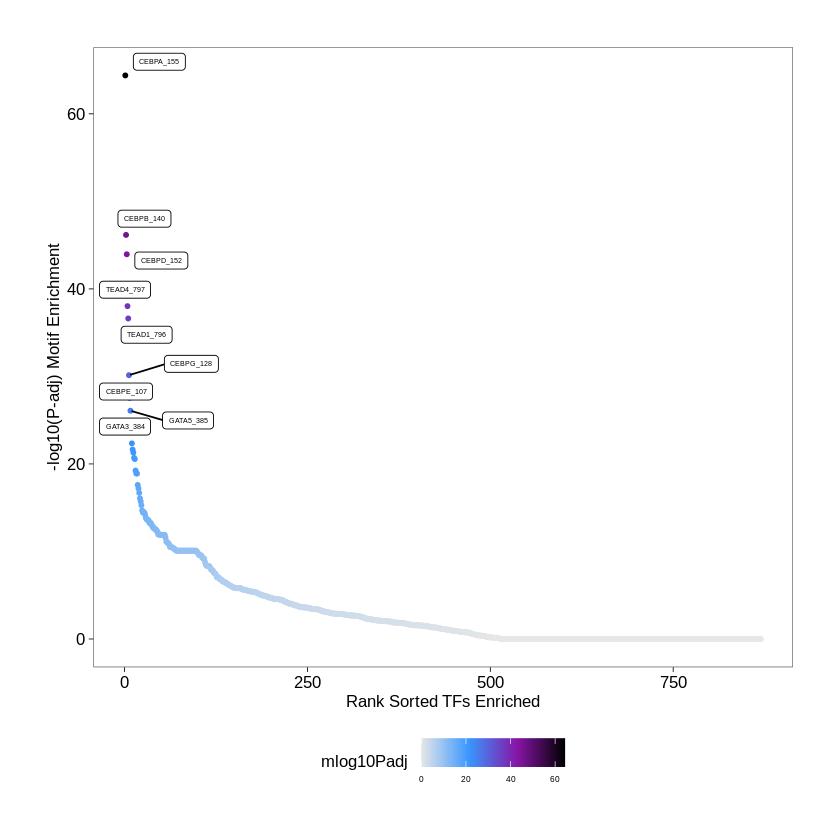

In [57]:
ggUp <- ggplot(df, aes(rank, mlog10Padj, color = mlog10Padj)) + 
  geom_point(size = 1) +
  ggrepel::geom_label_repel(
        data = df[rev(seq_len(30)), ], aes(x = rank, y = mlog10Padj, label = TF), 
        size = 1.5,
        nudge_x = 2,
        color = "black"
  ) + theme_ArchR() + 
  ylab("-log10(P-adj) Motif Enrichment") + 
  xlab("Rank Sorted TFs Enriched") +
  scale_color_gradientn(colors = paletteContinuous(set = "comet"))

ggUp

In [60]:
proj <- addBgdPeaks(proj, method='Archr') # method ArchR bc of error ?

Identifying Background Peaks!



In [61]:
proj <- addDeviationsMatrix(
  ArchRProj = proj, 
  peakAnnotation = "Motif",
  force = TRUE
)

Using Previous Background Peaks!

ArchR logging to : ArchRLogs/ArchR-addDeviationsMatrix-3f0c45d1be963-Date-2021-12-03_Time-17-39-32.log
If there is an issue, please report to github with logFile!



NULL


2021-12-03 17:39:36 : Batch Execution w/ safelapply!, 0 mins elapsed.

2021-12-03 17:39:38 : chromVAR deviations rabbit (1 of 1) Schep (2017), 0.029 mins elapsed.

2021-12-03 17:40:27 : rabbit (1 of 1) : Deviations for Annotation 43 of 870, 0.656 mins elapsed.

2021-12-03 17:41:07 : rabbit (1 of 1) : Deviations for Annotation 86 of 870, 1.325 mins elapsed.

2021-12-03 17:41:39 : rabbit (1 of 1) : Deviations for Annotation 129 of 870, 1.846 mins elapsed.

2021-12-03 17:42:17 : rabbit (1 of 1) : Deviations for Annotation 172 of 870, 2.478 mins elapsed.

2021-12-03 17:43:02 : rabbit (1 of 1) : Deviations for Annotation 215 of 870, 3.241 mins elapsed.

2021-12-03 17:43:45 : rabbit (1 of 1) : Deviations for Annotation 258 of 870, 3.951 mins elapsed.

2021-12-03 17:44:23 : rabbit (1 of 1) : Deviations for Annotation 301 of 870, 4.589 mins elapsed.

2021-12-03 17:44:56 : rabbit (1 of 1) : Deviations for Annotation 344 of 870, 5.136 mins elapsed.

2021-12-03 17:45:54 : rabbit (1 of 1) : Deviat

In [62]:
plotVarDev <- getVarDeviations(proj, name = "MotifMatrix", plot = TRUE)

DataFrame with 6 rows and 6 columns
     seqnames     idx      name combinedVars combinedMeans      rank
        <Rle> <array>   <array>    <numeric>     <numeric> <integer>
f688        z     688 HNF4G_688      23.9186     -0.405112         1
f662        z     662 HNF4A_662      22.2440     -0.373093         2
f692        z     692 NR2F1_692      15.1876     -0.315625         3
f383        z     383 GATA1_383      14.5032      0.125622         4
f3          z       3  TFAP2C_3      14.2941     -0.297320         5
f695        z     695  RXRA_695      14.1863     -0.297974         6


Warning message:
"ggrepel: 19 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


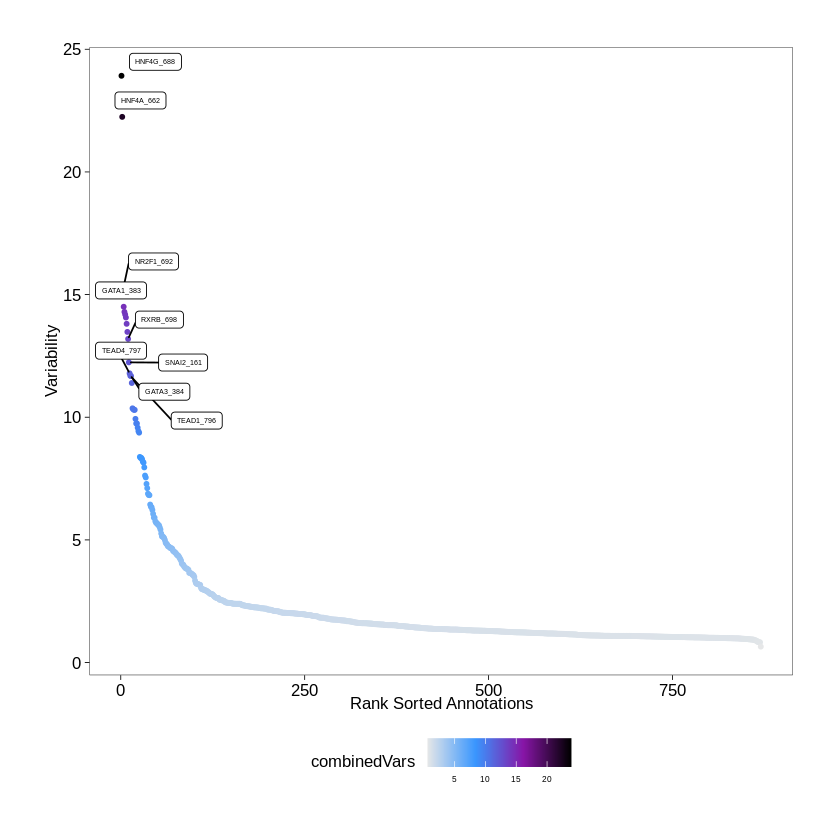

In [63]:
plotVarDev

[1] "z:TBX21_780"          "z:PAX5_709"           "z:IRF4_632"          
 [4] "z:GATA1_383"          "z:CEBPA_155"          "z:EBF1_67"           
 [7] "z:SREBF1_22"          "deviations:TBX21_780" "deviations:PAX5_709" 
[10] "deviations:IRF4_632"  "deviations:GATA1_383" "deviations:CEBPA_155"
[13] "deviations:EBF1_67"   "deviations:SREBF1_22"

[1] "z:TBX21_780" "z:PAX5_709"  "z:IRF4_632"  "z:GATA1_383" "z:CEBPA_155"
[6] "z:EBF1_67"

Getting ImputeWeights

No imputeWeights found, returning NULL

Getting Matrix Values...

2021-12-03 17:54:17 : 

1 


1 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."
2 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."
3 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."
4 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."
5 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."
6 
Warning message:
"`expand_scale()` is deprecated; use `expansion()` instead."


Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `guides(<scale> = "none")` instead."
Warning message:
"`guides(<scale> = FALSE)` is deprecated. Please use `gu

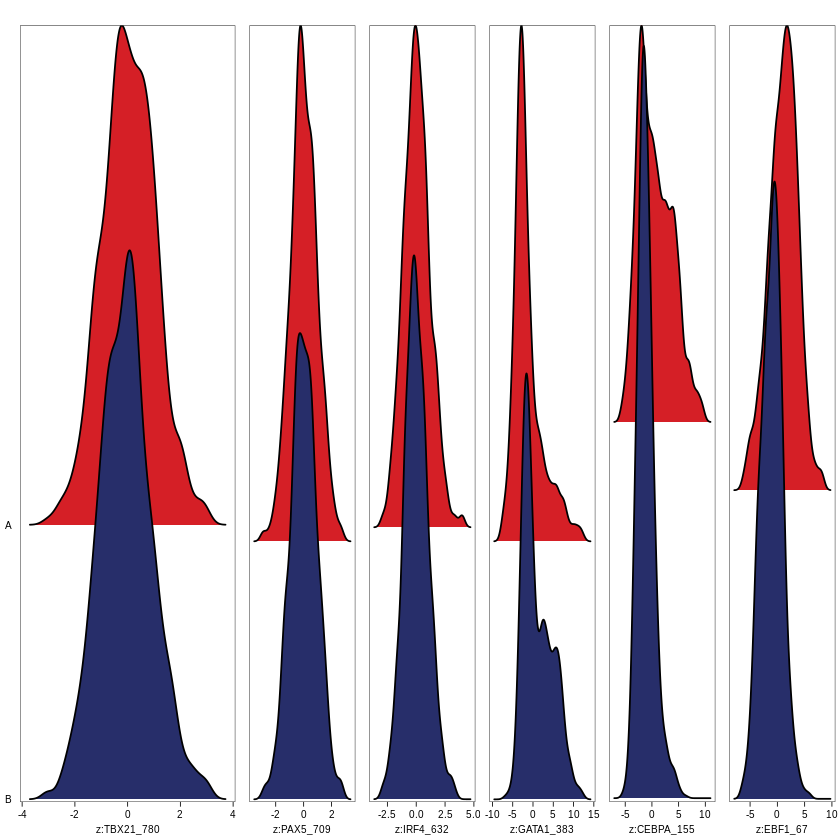

In [64]:
motifs <- c("GATA1", "CEBPA", "EBF1", "IRF4", "TBX21", "PAX5")
markerMotifs <- getFeatures(proj, select = paste(motifs, collapse="|"), useMatrix = "MotifMatrix")
markerMotifs

markerMotifs <- grep("z:", markerMotifs, value = TRUE)
markerMotifs <- markerMotifs[markerMotifs %ni% "z:SREBF1_22"]
markerMotifs

p <- plotGroups(ArchRProj = proj, 
  groupBy = "CLUST", 
  colorBy = "MotifMatrix", 
  name = markerMotifs#,
 # imputeWeights = getImputeWeights(projHeme5)
)

p2 <- lapply(seq_along(p), function(x){
  if(x != 1){
    p[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.text.y=element_blank(), 
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }else{
    p[[x]] + guides(color = FALSE, fill = FALSE) + 
    theme_ArchR(baseSize = 6) +
    theme(plot.margin = unit(c(0.1, 0.1, 0.1, 0.1), "cm")) +
    theme(
        axis.ticks.y=element_blank(),
        axis.title.y=element_blank()
    ) + ylab("")
  }
})
do.call(cowplot::plot_grid, c(list(nrow = 1, rel_widths = c(2, rep(1, length(p2) - 1))),p2))

In [35]:
proj


           ___      .______        ______  __    __  .______      
          /   \     |   _  \      /      ||  |  |  | |   _  \     
         /  ^  \    |  |_)  |    |  ,----'|  |__|  | |  |_)  |    
        /  /_\  \   |      /     |  |     |   __   | |      /     
       /  _____  \  |  |\  \\___ |  `----.|  |  |  | |  |\  \\___.
      /__/     \__\ | _| `._____| \______||__|  |__| | _| `._____|
    



class: ArchRProject 
outputDirectory: /rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/Archr/Project 
samples(1): rabbit
sampleColData names(1): ArrowFiles
cellColData names(12): Sample TSSEnrichment ... nDiFrags CLUST
numberOfCells(1): 2483
medianTSS(1): 3.441
medianFrags(1): 18194

### UCSC w chr Prefix

In [24]:
seqstyle = 'UCSC'
#seqstyle = 'NCBI'
seqlevelsStyle(genomeAnnotation$chromSizes) <- seqstyle
seqlevelsStyle(geneAnnotation$genes) <- seqstyle
seqlevelsStyle(geneAnnotation$TSS) <- seqstyle
seqlevelsStyle(geneAnnotation$exons) <- seqstyle
seqlevelsStyle(BSgenome.Ocuniculus.NCBI.oryCun2) <- seqstyle

#important as rabbit chromosome dont have the 'chr' prefix
addArchRChrPrefix(chrPrefix = FALSE)

ArchR is now disabling the requirement of chromosome prefix = 'chr'



In [25]:
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC'
#fragment_files = "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/test_fragments.tsv.gz"
fragment_files = "/TEST/BGRGP4_fragments.tsv.gz"

In [ ]:
opts$min.fragments <- 2500
opts$filterTSS.score <- 2.5 # May need to rerun with threshold at 2

#Create Arrow File for filtered samples, filtered using Signac's filter for ATAC
ArrowFiles <- createArrowFiles(
  inputFiles = paste0(io$basedir, fragment_files),
  sampleNames = paste0('rabbit'),
  minTSS = opts$filterTSS.score, #Dont set this too high because you can always increase later
  minFrags = opts$min.fragments , 
  addTileMat = TRUE,
  addGeneScoreMat = FALSE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation,
  force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW02

ArchR logging to : ArchRLogs/ArchR-createArrows-3f0c44a6ae06b-Date-2021-12-03_Time-16-20-48.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2021-12-03 16:20:48 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit : 1 of 1) Checking if completed file exists!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Arrow Exists! Overriding since force = TRUE!, 0 mins elapsed.

(rabbit : 1 of 1) Determining Arrow Method to use!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.003 mins elapsed.

2021-12-03 16:20:48 : (rabbit : 1 of 1) Tabix Bed To Temporary File, 0.004 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:1-38970151

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:38970152-77940302

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:77940303-116910454

(rabbit : 1 of 1) found fragments when removed chromosome pr

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:6231311-9346965

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:9346966-12462620

Warning message in sprintf("%s Reading TabixFile %s Percent", prefix, round(100 * :
"one argument not used by format '%s Reading TabixFile %s Percent'"
2021-12-03 16:37:27 : (rabbit : 1 of 1) Reading TabixFile 64 Percent, 16.65 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:12462621-15578276

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:1-31138221

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:31138222-62276442

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:62276443-93414663

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:93414664-124552884

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:124552885-155691105

(rabbit : 1 of 1) found fragments

In [ ]:
ArrowFiles = list.files(file.path(io$output.directory, 'Archr'), pattern ='arrow')

In [ ]:
ArrowFiles

In [ ]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

In [ ]:
proj

In [ ]:
proj@cellColData$CLUST = c(rep('A', 1000), rep('B', nrow(proj@cellColData)-1000))

In [ ]:
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "CLUST")

### NCBI w/o chr Prefix

In [24]:
#seqstyle = 'UCSC'
seqstyle = 'NCBI'
seqlevelsStyle(genomeAnnotation$chromSizes) <- seqstyle
seqlevelsStyle(geneAnnotation$genes) <- seqstyle
seqlevelsStyle(geneAnnotation$TSS) <- seqstyle
seqlevelsStyle(geneAnnotation$exons) <- seqstyle
seqlevelsStyle(BSgenome.Ocuniculus.NCBI.oryCun2) <- seqstyle

#important as rabbit chromosome dont have the 'chr' prefix
addArchRChrPrefix(chrPrefix = FALSE)

ArchR is now disabling the requirement of chromosome prefix = 'chr'



In [25]:
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC'
#fragment_files = "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/test_fragments.tsv.gz"
fragment_files = "/TEST/BGRGP4_fragments.tsv.gz"

In [ ]:
opts$min.fragments <- 2500
opts$filterTSS.score <- 2.5 # May need to rerun with threshold at 2

#Create Arrow File for filtered samples, filtered using Signac's filter for ATAC
ArrowFiles <- createArrowFiles(
  inputFiles = paste0(io$basedir, fragment_files),
  sampleNames = paste0('rabbit'),
  minTSS = opts$filterTSS.score, #Dont set this too high because you can always increase later
  minFrags = opts$min.fragments , 
  addTileMat = TRUE,
  addGeneScoreMat = FALSE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation,
  force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW02

ArchR logging to : ArchRLogs/ArchR-createArrows-3f0c44a6ae06b-Date-2021-12-03_Time-16-20-48.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2021-12-03 16:20:48 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit : 1 of 1) Checking if completed file exists!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Arrow Exists! Overriding since force = TRUE!, 0 mins elapsed.

(rabbit : 1 of 1) Determining Arrow Method to use!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.003 mins elapsed.

2021-12-03 16:20:48 : (rabbit : 1 of 1) Tabix Bed To Temporary File, 0.004 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:1-38970151

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:38970152-77940302

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:77940303-116910454

(rabbit : 1 of 1) found fragments when removed chromosome pr

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:6231311-9346965

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:9346966-12462620

Warning message in sprintf("%s Reading TabixFile %s Percent", prefix, round(100 * :
"one argument not used by format '%s Reading TabixFile %s Percent'"
2021-12-03 16:37:27 : (rabbit : 1 of 1) Reading TabixFile 64 Percent, 16.65 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:12462621-15578276

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:1-31138221

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:31138222-62276442

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:62276443-93414663

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:93414664-124552884

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:124552885-155691105

(rabbit : 1 of 1) found fragments

In [ ]:
ArrowFiles = list.files(file.path(io$output.directory, 'Archr'), pattern ='arrow')

In [ ]:
ArrowFiles

In [ ]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

In [ ]:
proj

In [ ]:
proj@cellColData$CLUST = c(rep('A', 1000), rep('B', nrow(proj@cellColData)-1000))

In [ ]:
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "CLUST")

### NCBI w chr Prefix

In [24]:
#seqstyle = 'UCSC'
seqstyle = 'NCBI'
seqlevelsStyle(genomeAnnotation$chromSizes) <- seqstyle
seqlevelsStyle(geneAnnotation$genes) <- seqstyle
seqlevelsStyle(geneAnnotation$TSS) <- seqstyle
seqlevelsStyle(geneAnnotation$exons) <- seqstyle
seqlevelsStyle(BSgenome.Ocuniculus.NCBI.oryCun2) <- seqstyle

#important as rabbit chromosome dont have the 'chr' prefix
addArchRChrPrefix(chrPrefix = TRUE)

ArchR is now disabling the requirement of chromosome prefix = 'chr'



In [25]:
io$basedir='/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC'
#fragment_files = "/rds/project/rds-SDzz0CATGms/users/bt392/04_Rabbit_ATAC/TEST/test_fragments.tsv.gz"
fragment_files = "/TEST/BGRGP4_fragments.tsv.gz"

In [ ]:
opts$min.fragments <- 2500
opts$filterTSS.score <- 2.5 # May need to rerun with threshold at 2

#Create Arrow File for filtered samples, filtered using Signac's filter for ATAC
ArrowFiles <- createArrowFiles(
  inputFiles = paste0(io$basedir, fragment_files),
  sampleNames = paste0('rabbit'),
  minTSS = opts$filterTSS.score, #Dont set this too high because you can always increase later
  minFrags = opts$min.fragments , 
  addTileMat = TRUE,
  addGeneScoreMat = FALSE,
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation,
  force=TRUE
)

Found Gene Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found Exon Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW0

Found TSS Seqnames not in GenomeAnnotation chromSizes, Removing : chrM,AAGW02076170,AAGW02077230,AAGW02077833,AAGW02078230,AAGW02078537,AAGW02078775,AAGW02078982,AAGW02079106,AAGW02079147,AAGW02079168,AAGW02079214,AAGW02079242,AAGW02079307,AAGW02079327,AAGW02079371,AAGW02079515,AAGW02079587,AAGW02079588,AAGW02079657,AAGW02079658,AAGW02079674,AAGW02079688,AAGW02079913,AAGW02079997,AAGW02080057,AAGW02080074,AAGW02080085,AAGW02080103,AAGW02080168,AAGW02080217,AAGW02080234,AAGW02080240,AAGW02080326,AAGW02080430,AAGW02080442,AAGW02080504,AAGW02080517,AAGW02080613,AAGW02080699,AAGW02080733,AAGW02080735,AAGW02080770,AAGW02080791,AAGW02080820,AAGW02080821,AAGW02080938,AAGW02080941,AAGW02080961,AAGW02080967,AAGW02080980,AAGW02081012,AAGW02081119,AAGW02081122,AAGW02081136,AAGW02081154,AAGW02081155,AAGW02081156,AAGW02081157,AAGW02081158,AAGW02081159,AAGW02081160,AAGW02081161,AAGW02081169,AAGW02081209,AAGW02081222,AAGW02081234,AAGW02081239,AAGW02081247,AAGW02081253,AAGW02081303,AAGW02081305,AAGW02

ArchR logging to : ArchRLogs/ArchR-createArrows-3f0c44a6ae06b-Date-2021-12-03_Time-16-20-48.log
If there is an issue, please report to github with logFile!

Cleaning Temporary Files

2021-12-03 16:20:48 : Batch Execution w/ safelapply!, 0 mins elapsed.

(rabbit : 1 of 1) Checking if completed file exists!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Arrow Exists! Overriding since force = TRUE!, 0 mins elapsed.

(rabbit : 1 of 1) Determining Arrow Method to use!

2021-12-03 16:20:48 : (rabbit : 1 of 1) Reading In Fragments from inputFiles (readMethod = tabix), 0.003 mins elapsed.

2021-12-03 16:20:48 : (rabbit : 1 of 1) Tabix Bed To Temporary File, 0.004 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:1-38970151

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:38970152-77940302

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr1:77940303-116910454

(rabbit : 1 of 1) found fragments when removed chromosome pr

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:6231311-9346965

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:9346966-12462620

Warning message in sprintf("%s Reading TabixFile %s Percent", prefix, round(100 * :
"one argument not used by format '%s Reading TabixFile %s Percent'"
2021-12-03 16:37:27 : (rabbit : 1 of 1) Reading TabixFile 64 Percent, 16.65 mins elapsed.

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr21:12462621-15578276

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:1-31138221

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:31138222-62276442

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:62276443-93414663

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:93414664-124552884

(rabbit : 1 of 1) found fragments when removed chromosome prefix : chr3:124552885-155691105

(rabbit : 1 of 1) found fragments

In [ ]:
ArrowFiles = list.files(file.path(io$output.directory, 'Archr'), pattern ='arrow')

In [ ]:
ArrowFiles

In [ ]:
proj <- ArchRProject(
  ArrowFiles = ArrowFiles, 
  outputDirectory = "Project",
  copyArrows = TRUE, #This is recommened so that you maintain an unaltered copy for later usage.
  geneAnnotation = geneAnnotation,
  genomeAnnotation = genomeAnnotation
)

In [ ]:
proj

In [ ]:
proj@cellColData$CLUST = c(rep('A', 1000), rep('B', nrow(proj@cellColData)-1000))

In [ ]:
proj <- addGroupCoverages(ArchRProj = proj, groupBy = "CLUST")